In [1]:
%pip install scikit-learn umap-learn seaborn matplotlib pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:

import pandas as pd

df = pd.read_csv("spotify dataset.csv")

In [3]:

df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [28]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

df.dropna(subset=['track_name', 'track_artist', 'track_album_name'], inplace=True)
df.reset_index(drop=True, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

num_cols = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness','instrumentalness', 'liveness', 'valence',
            'tempo', 'duration_ms' ]
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

cat_cols = ['playlist_genre', 'playlist_name', 'track_artist', 'track_album_name']
encoder = LabelEncoder()
for col in cat_cols:
  df[col] = encoder.fit_transform(df[col])

df.to_csv("spotify_preprocessed.csv", index=False)

df.head()


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,Cluster
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,2782,66,2oCs0DGTsRO98Gh5ZSl2Cx,7614,2019-06-14,292,37i9dQZF1DXcZDD7cfEKhW,2,...,0.918090,1,0.063508,0.102616,0.000000,0.065562,0.522704,0.509673,0.371254,2
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,6084,67,63rPSO264uRjW1X5E6cWv6,10410,2019-12-13,292,37i9dQZF1DXcZDD7cfEKhW,2,...,0.869162,1,0.040632,0.072837,0.004235,0.358434,0.699294,0.417524,0.308674,2
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,10416,70,1HoSmj2eLcsrR0vE9gThr4,985,2019-07-05,292,37i9dQZF1DXcZDD7cfEKhW,2,...,0.901368,0,0.080828,0.079879,0.000023,0.110442,0.618567,0.517908,0.335953,2
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,9215,60,1nqYsOef1yKKuGOVchbsk6,2798,2019-07-19,292,37i9dQZF1DXcZDD7cfEKhW,2,...,0.894118,1,0.111111,0.028873,0.000009,0.204819,0.279516,0.509338,0.321311,2
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,5402,69,7m7vv9wlQ4i0LFuJiE2zsQ,14843,2019-03-05,292,37i9dQZF1DXcZDD7cfEKhW,2,...,0.875385,1,0.039107,0.080785,0.000000,0.083635,0.731584,0.517775,0.360156,2


<Figure size 1200x800 with 0 Axes>

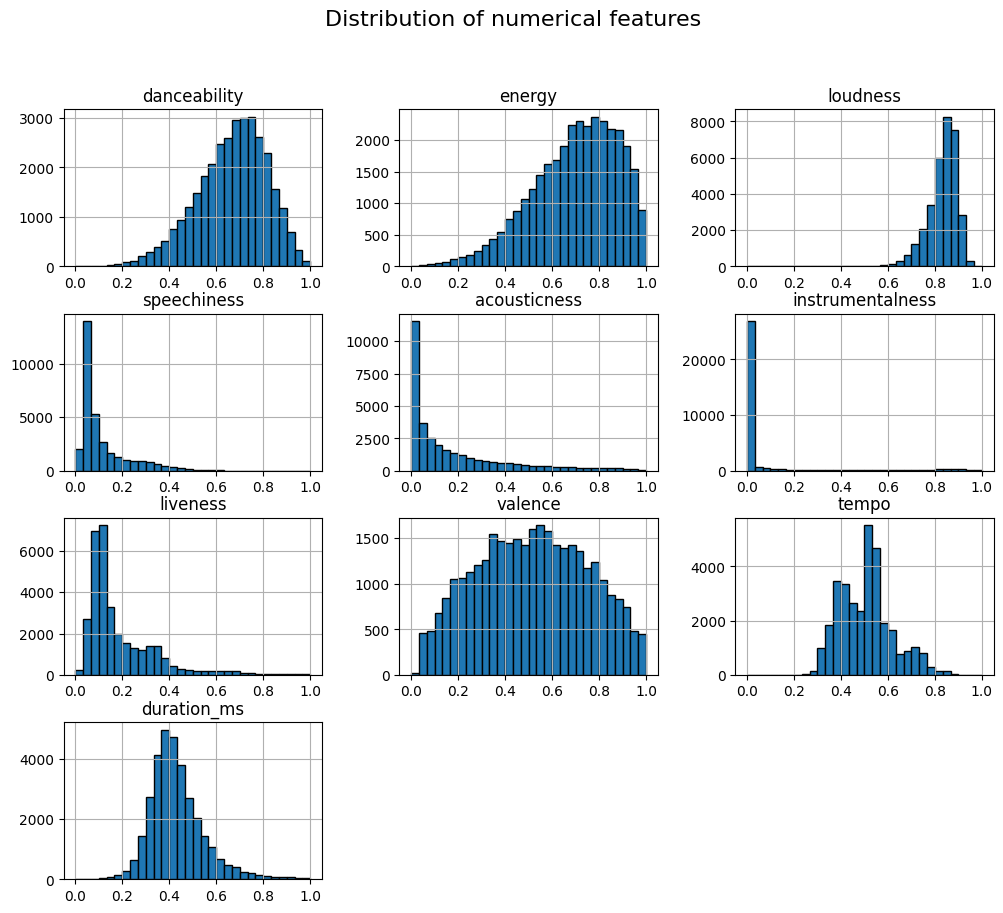

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

num_cols = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness','instrumentalness', 'liveness', 'valence',
            'tempo', 'duration_ms' ]

plt.figure(figsize=(12,8))
df[num_cols].hist(bins=30, figsize = (12,10), layout = (4,3), edgecolor = "black")
plt.suptitle('Distribution of numerical features', fontsize=16)
plt.show()

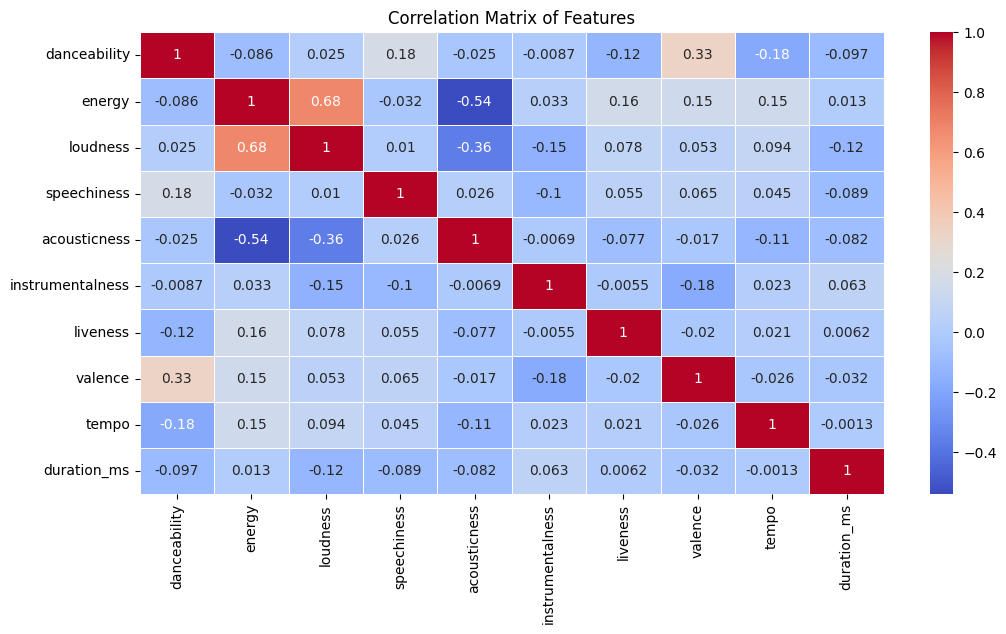

In [30]:
plt.figure(figsize=(12,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix of Features")
plt.show()

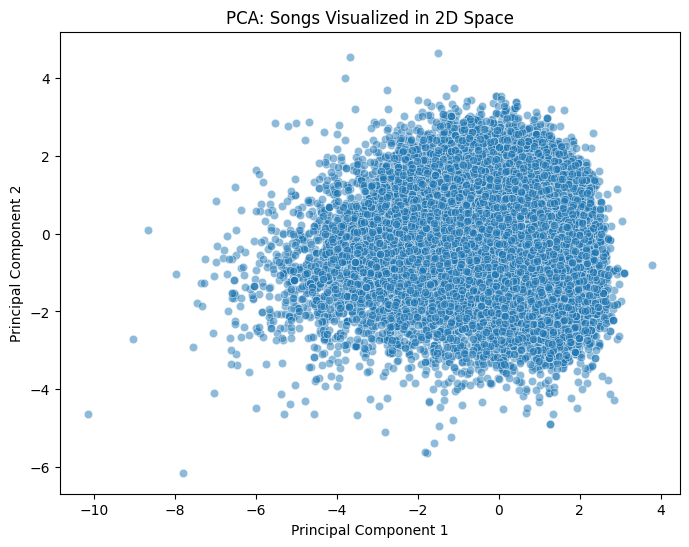

In [31]:
df_scaled = StandardScaler().fit_transform(df[num_cols])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(data=pca_result, columns=['PCA1', 'PCA2'])

plt.figure(figsize=(8,6))
sns.scatterplot(x=df_pca['PCA1'], y=df_pca['PCA2'], alpha=0.5)
plt.title("PCA: Songs Visualized in 2D Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


In [ ]:
%pip install umap-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\Jenni\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


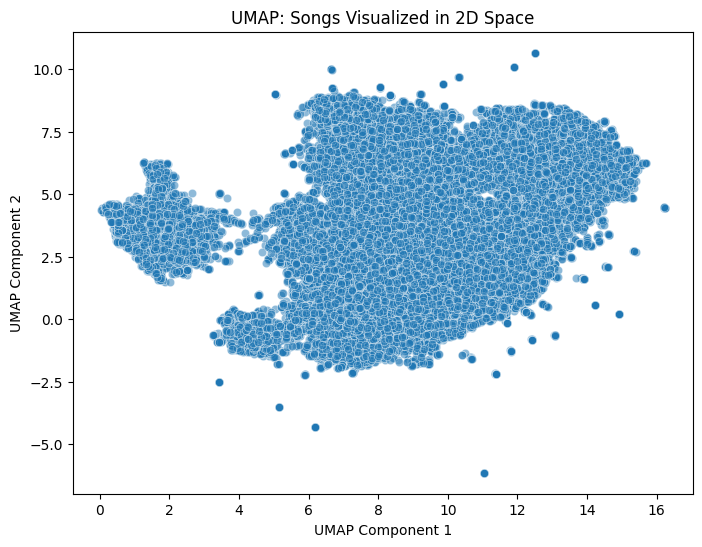

In [32]:
import umap
umap_result = umap.UMAP(n_components=2, random_state=42).fit_transform(df_scaled)

df_umap = pd.DataFrame(data=umap_result, columns=['UMAP1', 'UMAP2'])
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_umap['UMAP1'], y=df_umap['UMAP2'], alpha=0.5)
plt.title("UMAP: Songs Visualized in 2D Space")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.show()


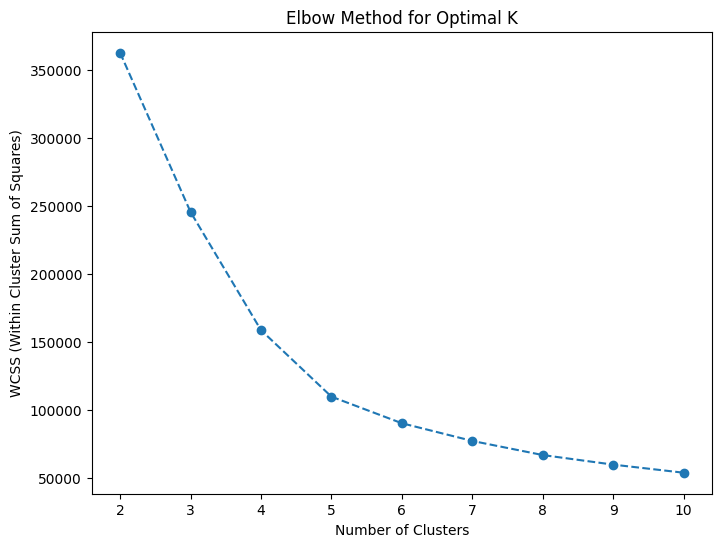

In [33]:
from sklearn.cluster import KMeans

wcss = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(umap_result)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), wcss, marker='o', linestyle='--')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS (Within Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal K")
plt.show()


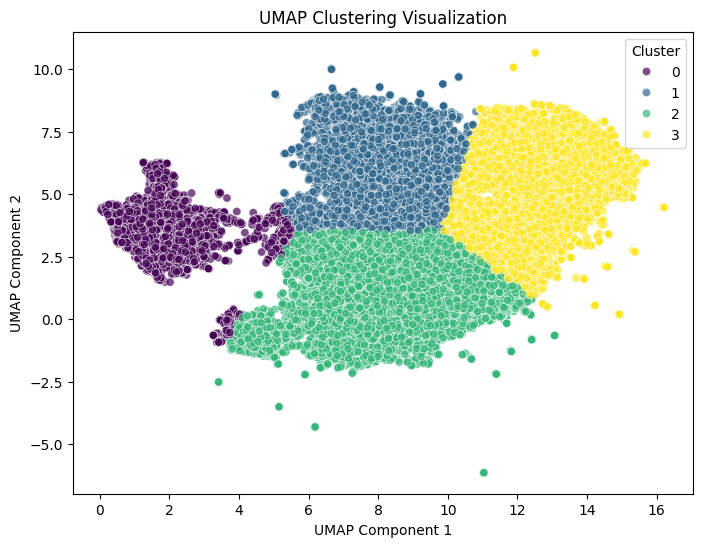

In [34]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(umap_result)

df["Cluster"] = clusters

import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df_umap["UMAP1"],
    y=df_umap["UMAP2"],
    hue=df["Cluster"],
    palette="viridis",
    alpha=0.7
)

plt.title("UMAP Clustering Visualization")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.show()


In [35]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

feature_matrix = StandardScaler().fit_transform(df[num_cols])
similarity_matrix = cosine_similarity(feature_matrix)

track_id_to_idx = pd.Series(df.index, index=df["track_id"]).to_dict()


def recommend_songs(track_name=None, track_id=None, n=5,
                    same_cluster_only=True,
                    use_popularity_tiebreak=True):

    if track_id is not None:
        if track_id not in track_id_to_idx:
            raise ValueError(f"track_id '{track_id}' not found.")
        idx = track_id_to_idx[track_id]

    elif track_name is not None:
        matches = df[df["track_name"].str.lower() == track_name.lower()]

        if matches.empty:
            matches = df[df["track_name"].str.lower().str.contains(track_name.lower(), na=False)]

        if matches.empty:
            raise ValueError(f"No track found matching '{track_name}'.")

        idx = matches.index[0]

    else:
        raise ValueError("Provide either track_name or track_id.")

    seed = df.loc[idx]

    sims = similarity_matrix[idx].copy()
    sims[idx] = -1

    candidate_idx = np.arange(len(df))

    if same_cluster_only and "Cluster" in df.columns:
        candidate_idx = df.index[df["Cluster"] == seed["Cluster"]].to_numpy()

    candidate_scores = pd.DataFrame({
        "idx": candidate_idx,
        "similarity": sims[candidate_idx]
    })

    if use_popularity_tiebreak and "track_popularity" in df.columns:
        candidate_scores["popularity"] = df.loc[candidate_idx, "track_popularity"].values
        candidate_scores = candidate_scores.sort_values(
            by=["similarity", "popularity"],
            ascending=[False, False]
        )
    else:
        candidate_scores = candidate_scores.sort_values(
            by="similarity",
            ascending=False
        )

    top_idx = candidate_scores["idx"].head(n).tolist()

    result = df.loc[top_idx, [
        "track_name",
        "track_artist",
        "playlist_genre",
        "track_popularity"
    ]].copy()

    result.insert(
        0,
        "similarity_score",
        candidate_scores.set_index("idx").loc[top_idx, "similarity"].round(3).values
    )

    print(f"Recommendations based on: {seed['track_name']} - {seed['track_artist']}")

    return result.reset_index(drop=True)


def export_sample_recommendations(sample_size=5, n=5,
                                  path="outputs/sample_recommendations.csv"):

    import os

    os.makedirs(os.path.dirname(path), exist_ok=True)

    sample_tracks = df.sample(sample_size, random_state=42)

    recommendations = []

    for _, row in sample_tracks.iterrows():
        recs = recommend_songs(track_id=row["track_id"], n=n)
        recs["seed_track"] = row["track_name"]
        recs["seed_artist"] = row["track_artist"]
        recommendations.append(recs)

    output = pd.concat(recommendations, ignore_index=True)
    output.to_csv(path, index=False)

    print(f"Recommendations saved to {path}")

    return output

In [36]:
recommend_songs(track_name="Believer", n=5)

Recommendations based on: Believer - 4080


,similarity_score,track_name,track_artist,playlist_genre,track_popularity
0,0.999,Believer,4080,1,12
1,0.999,Believer,4080,3,12
2,0.986,Believer,4080,2,11
3,0.973,YDLM,9296,2,52
4,0.971,Believer,4080,1,88
